# Ethics in AI lab 10
## Name - Manan Chahal
## Roll No - 23102C0044

### Topic - Ethical Dilemma Simulation in Autonomous Systems

This experiment simulates ethical decisions in autonomous systems such as self-driving cars. Different ethical models and tests AI working on those principals in various situations

In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [16]:
# Utilitarian save as many as possible
def utilitarian(peds, passengers):
    if peds > passengers:
        return "save_pedestrians"
    else:
        return "save_passengers"

# Deontological, save passengers
def deontological():
    return "save_passengers"


# Deontological leaning - prefer passengers
def deontological_leaning(peds, passengers):
    if peds > ((2)*passengers):
        return "save_pedestrians"
    else:
        return "save_passengers"


# Random decision (baseline comparison)
def random_decision():
    return random.choice(["save_pedestrians", "save_passengers"])

In [4]:
def generate_scenarios(n=100):
    scenarios = []

    for _ in range(n):
        pedestrians = random.randint(1,10)
        passengers = random.randint(1,5)

        scenarios.append({
            "pedestrians": pedestrians,
            "passengers": passengers
        })

    return pd.DataFrame(scenarios)

df = generate_scenarios(200)

df.head()

,pedestrians,passengers
0,6,3
1,5,2
2,6,3
3,6,3
4,1,1


In [18]:
def apply_policies(df):

    df["utilitarian"] = df.apply(
        lambda x: utilitarian(x["pedestrians"], x["passengers"]),
        axis=1
    )

    df["deontological"] = df.apply(
        lambda x: deontological(),
        axis=1
    )

    df["deontological_leaning"] = df.apply(
        lambda x: deontological_leaning(x["pedestrians"], x["passengers"]),
        axis=1
    )

    df["random"] = df.apply(
        lambda x: random_decision(),
        axis=1
    )

    return df

df = apply_policies(df)

df.head()

,pedestrians,passengers,utilitarian,deontological,deontological_leaning,random
0,6,3,save_pedestrians,save_passengers,save_passengers,save_passengers
1,5,2,save_pedestrians,save_passengers,save_pedestrians,save_passengers
2,6,3,save_pedestrians,save_passengers,save_passengers,save_passengers
3,6,3,save_pedestrians,save_passengers,save_passengers,save_passengers
4,1,1,save_passengers,save_passengers,save_passengers,save_pedestrians


In [19]:
def compute_outcomes(df, policy):

    saved = 0
    sacrificed = 0

    for _, row in df.iterrows():

        decision = row[policy]

        if decision == "save_pedestrians":
            saved += row["pedestrians"]
            sacrificed += row["passengers"]

        else:
            saved += row["passengers"]
            sacrificed += row["pedestrians"]

    return saved, sacrificed


results = {}

for policy in ["utilitarian", "deontological","deontological_leaning", "random"]:

    saved, sacrificed = compute_outcomes(df, policy)

    results[policy] = {
        "saved": saved,
        "sacrificed": sacrificed
    }

results

{'utilitarian': {'saved': 1212, 'sacrificed': 510},
 'deontological': {'saved': 595, 'sacrificed': 1127},
 'deontological_leaning': {'saved': 1063, 'sacrificed': 659},
 'random': {'saved': 866, 'sacrificed': 856}}

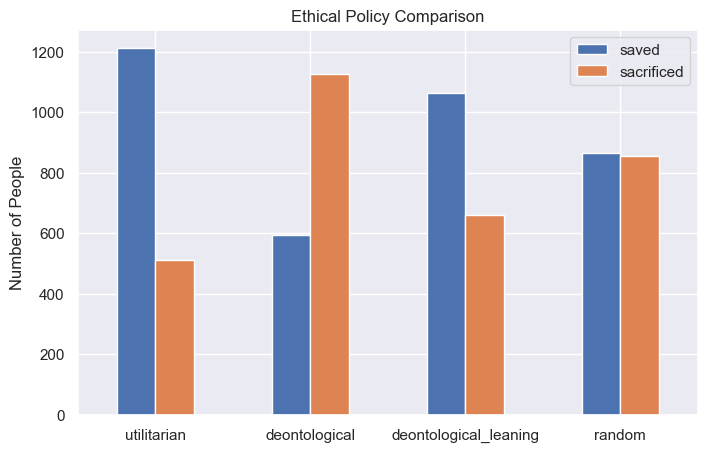

In [20]:
result_df = pd.DataFrame(results).T

result_df.plot(kind="bar", figsize=(8,5))
plt.title("Ethical Policy Comparison")
plt.ylabel("Number of People")
plt.xticks(rotation=0)
plt.show()

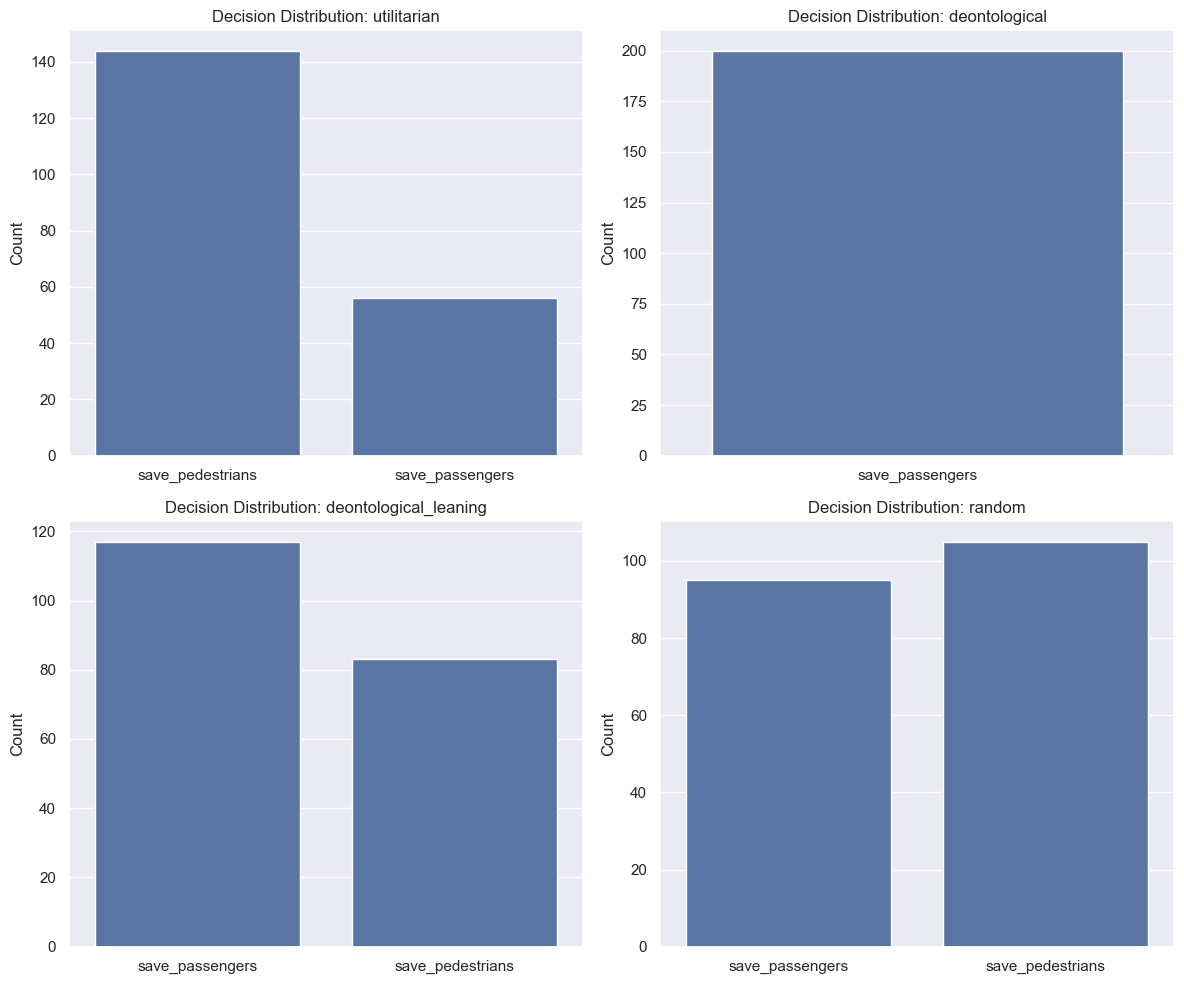

In [23]:
policies = ["utilitarian", "deontological", "deontological_leaning", "random"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid
axes = axes.flatten()  # make indexing easier

for i, policy in enumerate(policies):
    sns.countplot(x=df[policy], ax=axes[i])
    axes[i].set_title(f"Decision Distribution: {policy}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

This experiment illustrates how different ethical decision-making approaches can influence the behavior of autonomous systems when faced with moral dilemmas. The utilitarian approach focuses on minimizing overall harm by favoring outcomes that benefit the greatest number of individuals, whereas the deontological approach adheres to fixed rules or duties, such as prioritizing passenger safety regardless of the situation. The inclusion of a random strategy provides a neutral baseline to better understand the impact of structured ethical reasoning. Overall, the findings demonstrate that the choice of ethical framework plays a crucial role in shaping AI decisions, highlighting the need for thoughtful integration of ethical principles when developing autonomous technologies for real-world use.